In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import concatenate_utt_per_chapter

In [ ]:
importlib.reload(concatenate_utt_per_chapter)

In [15]:
mqi_df, class_df, utterances_df = concatenate_utt_per_chapter.read_files()

In [16]:
mqi_df.head()

,NCTETID,DISTRICT,MQI_11,MQI_12,MQI_13,OBSID,RATERID,SEGMENT,SCHOOLYEAR_SP,OBSYEAR,...,TREMSTU,STUENG,CLMATINQ,LESSEFFIC,DENSMAT,LATASK,LESSCLEAR,TASKDEVMAT,ERRANN,WORLD
0,2501,13,1,0,0,1140,30,1,2011,2011,...,999,999,999,999,999,999,999,999,999,999
1,2501,13,1,0,0,1140,30,1,2011,2011,...,999,999,999,999,999,999,999,999,999,999
2,2501,13,1,0,0,1140,30,1,2011,2011,...,999,999,999,999,999,999,999,999,999,999
3,2501,13,1,0,0,1140,30,0,2011,2011,...,999,999,999,999,999,999,999,999,999,999
4,2501,13,1,0,0,1140,57,1,2011,2011,...,999,999,999,999,999,999,999,999,999,999


In [18]:
utterances_df.head()

,speaker,text,year,OBSID,video_id,cleaned_text,num_words,turn_idx,comb_idx
0,teacher,"Friends, yesterday we started off by working o...",2,2119,706,friends yesterday we started off by working on...,13,0,2119_0
1,student,Yes.,2,2119,706,yes,1,1,2119_1
2,teacher,"And yesterday towards the end of the period, y...",2,2119,706,and yesterday towards the end of the period yo...,38,2,2119_2
3,multiple students,Yes.,2,2119,706,yes,1,3,2119_3
4,teacher,Some of you might be done. If you are finishe...,2,2119,706,some of you might be done if you are finished ...,106,4,2119_4


In [62]:
MQI_lesson_df, CLASS_lesson_df, subset_utt_df = concatenate_utt_per_chapter.cleaning(mqi_df, class_df, utterances_df)

In [63]:
MQI_lesson_df.head()

,OBSID,N_CHAP
0,10,8
1,100,7
2,1005,8
3,1006,4
4,1007,5


In [66]:
CLASS_lesson_df.head()

,OBSID,N_CHAP
0,10,4
1,100,4
2,1005,4
3,1006,2
4,1007,3


In [65]:
subset_utt_df.head()

,OBSID,combined_txt,num_words,turn_idx
0,2119,"teacher: Friends, yesterday we started off by ...",13,0
1,2119,student: Yes.,1,1
2,2119,teacher: And yesterday towards the end of the ...,38,2
3,2119,multiple students: Yes.,1,3
4,2119,teacher: Some of you might be done. If you ar...,106,4


In [70]:
# Add chapter assignments to utterances
MQI_utter_with_chap = concatenate_utt_per_chapter.assign_chapters(subset_utt_df, MQI_lesson_df)
CLASS_utter_with_chap = concatenate_utt_per_chapter.assign_chapters(subset_utt_df, CLASS_lesson_df)

In [71]:
MQI_utter_with_chap.head()

,OBSID,combined_txt,num_words,turn_idx,end_word,start_word,CHAPNUM
0,10,teacher: Okay. I think it’s working. Alright...,17,0,17,1,1
1,10,multiple students: Yes.,1,1,18,18,1
2,10,"teacher: Student M, you don’t have your homework?",8,2,26,19,1
3,10,student: No.,1,3,27,27,1
4,10,teacher: Did you hand it in?,5,4,32,28,1


In [72]:
CLASS_utter_with_chap.head()

,OBSID,combined_txt,num_words,turn_idx,end_word,start_word,CHAPNUM
0,10,teacher: Okay. I think it’s working. Alright...,17,0,17,1,1
1,10,multiple students: Yes.,1,1,18,18,1
2,10,"teacher: Student M, you don’t have your homework?",8,2,26,19,1
3,10,student: No.,1,3,27,27,1
4,10,teacher: Did you hand it in?,5,4,32,28,1


In [73]:
# dataset with utterances concatenated per chapter
MQI_all_utt_lesson = concatenate_utt_per_chapter.group_utterances_by_lesson(MQI_utter_with_chap)
MQI_all_utt_lesson.head()

,OBSID,full_text
0,10,teacher: Okay. I think it’s working. Alright...
1,100,teacher: Okay. Everybody please take out your...
2,1005,teacher: You're welcome. You don't need a pen...
3,1006,teacher: All right. At this point what we'll ...
4,1007,teacher: Okay. All right. We are going to re...


In [74]:
# datasets with utterances concatenated per chapter
MQI_all_utt_chap = concatenate_utt_per_chapter.group_utterances_by_chapter(MQI_utter_with_chap)
CLASS_all_utt_chap = concatenate_utt_per_chapter.group_utterances_by_chapter(CLASS_utter_with_chap)

In [75]:
MQI_all_utt_chap.head()

,OBSID,CHAPNUM,full_text
0,10,1,teacher: Okay. I think it’s working. Alright...
1,10,2,teacher: Okay. So 63 times 11 would equal 693...
2,10,3,teacher: Okay. I want one volunteer to solve ...
3,10,4,"teacher: Total. In division, this is the easi..."
4,10,5,"teacher: Okay, so you wrote like this? I want..."


In [76]:
CLASS_all_utt_chap.head()

,OBSID,CHAPNUM,full_text
0,10,1,teacher: Okay. I think it’s working. Alright...
1,10,2,student: 76 times 10 is 760.\nteacher: 760.\ns...
2,10,3,student: Lunar months.\nteacher: Not lunar mon...
3,10,4,teacher: I did and I said all three of you nee...
4,100,1,teacher: Okay. Everybody please take out your...


# Comparison between two .csv version

In [78]:
df1 = pd.read_csv("MQI_all_utt_chap.csv", dtype={"OBSID": "string"})
df2 = MQI_all_utt_chap

pd.testing.assert_frame_equal(df1, df2)

In [79]:
same = df1.equals(df2)  # strict
same_unordered = df1.sort_index(axis=1).sort_values(by=df1.columns.tolist()).reset_index(drop=True).equals(
    df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)
)

In [80]:
diff = df1.compare(df2)
print(diff)

Empty DataFrame
Columns: []
Index: []


In [81]:
df1 = pd.read_csv("CLASS_all_utt_chap.csv", dtype={"OBSID": "string"})
df2 = CLASS_all_utt_chap

pd.testing.assert_frame_equal(df1, df2)

In [82]:
same = df1.equals(df2)  # strict
same_unordered = df1.sort_index(axis=1).sort_values(by=df1.columns.tolist()).reset_index(drop=True).equals(
    df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)
)

In [83]:
diff = df1.compare(df2)
print(diff)

Empty DataFrame
Columns: []
Index: []


In [ ]:
diff = df1.compare(df2)
diff

# Distribution of chapter number per lesson

In [3]:
df = pd.read_csv("data\\Segmented transcripts\\MQI_all_utt_chap.csv")

chapters_per_course = df.groupby("OBSID")["CHAPNUM"].max()

# Descriptive stats
print("Number of courses:", chapters_per_course.shape[0])
print("Mean chapters per course:", chapters_per_course.mean())
print("Median:", chapters_per_course.median())
print("Min:", chapters_per_course.min())
print("Max:", chapters_per_course.max())
print("Std:", chapters_per_course.std())

Number of courses: 1658
Mean chapters per course: 7.41978287092883
Median: 8.0
Min: 2
Max: 13
Std: 1.4566417345830476


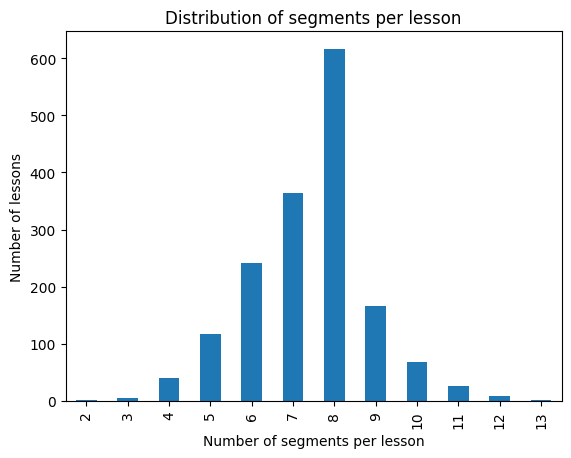

In [6]:
distribution = chapters_per_course.value_counts().sort_index()

distribution.plot(kind="bar")
plt.xlabel("Number of segments per lesson")
plt.ylabel("Number of lessons")
plt.title("Distribution of segments per lesson")
plt.show()